In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AQIdataset/city_day.csv')
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       24933 non-null  float64       
 3   PM10        18391 non-null  float64       
 4   NO          25949 non-null  float64       
 5   NO2         25946 non-null  float64       
 6   NOx         25346 non-null  float64       
 7   NH3         19203 non-null  float64       
 8   CO          27472 non-null  float64       
 9   SO2         25677 non-null  float64       
 10  O3          25509 non-null  float64       
 11  Benzene     23908 non-null  float64       
 12  Toluene     21490 non-null  float64       
 13  Xylene      11422 non-null  float64       
 14  AQI         24850 non-null  float64       
 15  AQI_Bucket  24850 non-null  object        
dtypes: datetime64[ns](1), 

### Data cleaning

In [ ]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [ ]:
(df.isna().mean() * 100).round(1)

,0
City,0.0
Date,0.0
PM2.5,15.6
PM10,37.7
NO,12.1
NO2,12.1
NOx,14.2
NH3,35.0
CO,7.0
SO2,13.1


In [ ]:
df = df.drop_duplicates()
df = df.sort_values(['City', 'Date']).reset_index(drop=True)
df.shape

(29531, 16)

In [ ]:
df = df.drop(columns=['Xylene'])
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [ ]:
pollutant_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']
(df[pollutant_cols] < 0).sum()

,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0
O3,0
Benzene,0


In [ ]:
df[pollutant_cols + ['AQI']].max()

,0
PM2.5,949.99
PM10,1000.00
NO,390.68
NO2,362.21
NOx,467.63
NH3,352.89
CO,175.81
SO2,193.86
O3,257.73
Benzene,455.03


In [ ]:
for col in pollutant_cols:
    df.loc[df[col] < 0, col] = np.nan

df.loc[df['PM2.5'] > 1000, 'PM2.5'] = np.nan
df.loc[df['PM10'] > 1500, 'PM10'] = np.nan

In [ ]:
fill_cols = pollutant_cols + ['AQI']

df[fill_cols] = (
    df.groupby('City')[fill_cols]
      .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

df[fill_cols].isna().sum()

,0
PM2.5,0
PM10,2009
NO,0
NO2,0
NOx,1169
NH3,2009
CO,0
SO2,0
O3,162
Benzene,2732


In [ ]:
def aqi_bucket(x):
    if pd.isna(x): return np.nan
    if x <= 50: return 'Good'
    if x <= 100: return 'Satisfactory'
    if x <= 200: return 'Moderate'
    if x <= 300: return 'Poor'
    if x <= 400: return 'Very Poor'
    return 'Severe'

df['AQI_Bucket'] = df['AQI'].apply(aqi_bucket)
df['AQI_Bucket'].value_counts()

,count
AQI_Bucket,
Moderate,10185
Satisfactory,10119
Poor,3358
Very Poor,2814
Good,1566
Severe,1489


In [ ]:
df.isna().sum()

,0
City,0
Date,0
PM2.5,0
PM10,2009
NO,0
NO2,0
NOx,1169
NH3,2009
CO,0
SO2,0


In [ ]:
df = df.drop(columns=['Benzene', 'Toluene'])
df.isna().sum()

,0
City,0
Date,0
PM2.5,0
PM10,2009
NO,0
NO2,0
NOx,1169
NH3,2009
CO,0
SO2,0


In [ ]:
df.to_csv('/content/drive/MyDrive/AQIdataset/city_day_cleaned.csv', index=False)

### Exploratory Data Analysis

In [ ]:
sns.set_style('whitegrid')

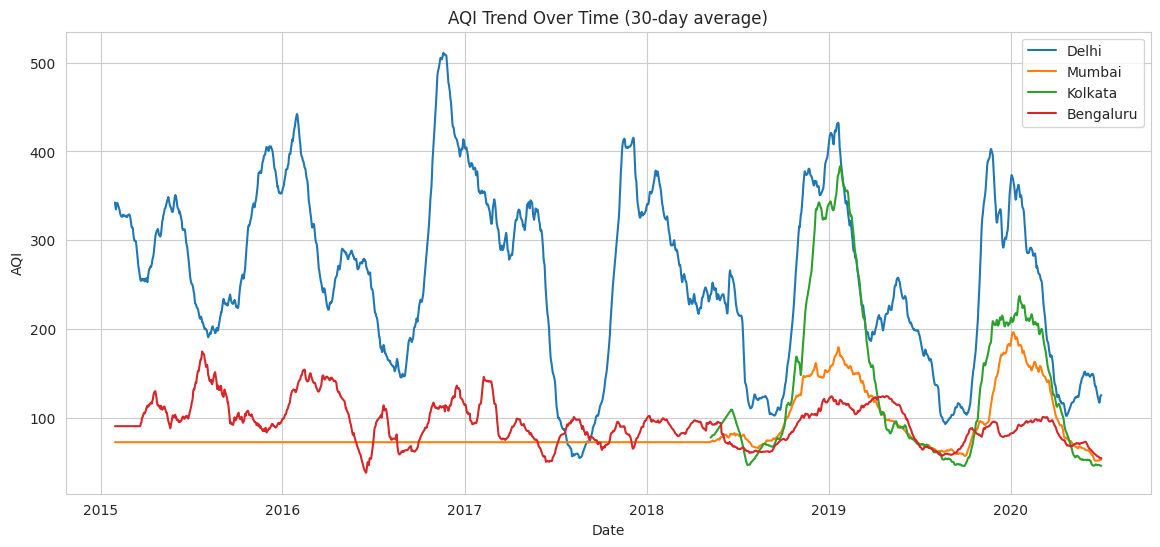

In [ ]:
cities = ['Delhi', 'Mumbai', 'Kolkata', 'Bengaluru']

plt.figure(figsize=(14, 6))
for c in cities:
    d = df[df['City'] == c].set_index('Date')['AQI'].rolling(30).mean()
    plt.plot(d, label=c)

plt.title('AQI Trend Over Time (30-day average)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()

In [ ]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df[['Date', 'Month', 'Year']].head()

,Date,Month,Year
0,2015-01-01,1,2015
1,2015-01-02,1,2015
2,2015-01-03,1,2015
3,2015-01-04,1,2015
4,2015-01-05,1,2015


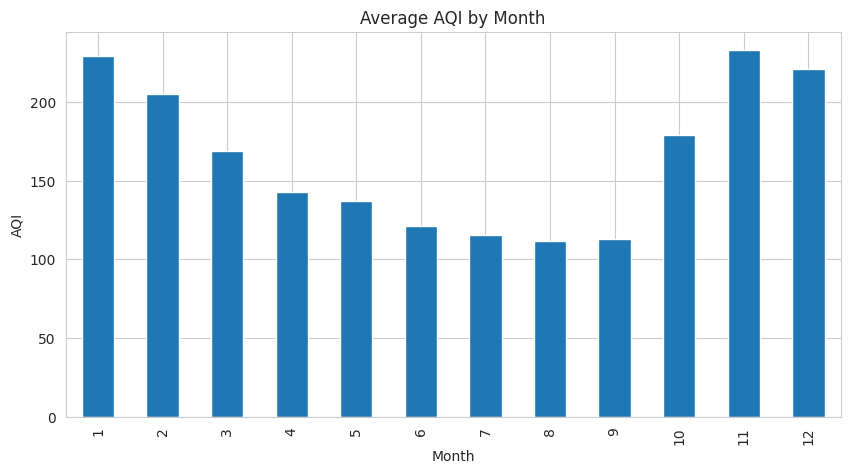

In [ ]:
df.groupby('Month')['AQI'].mean().plot(kind='bar', figsize=(10, 5))
plt.title('Average AQI by Month')
plt.xlabel('Month')
plt.ylabel('AQI')
plt.show()

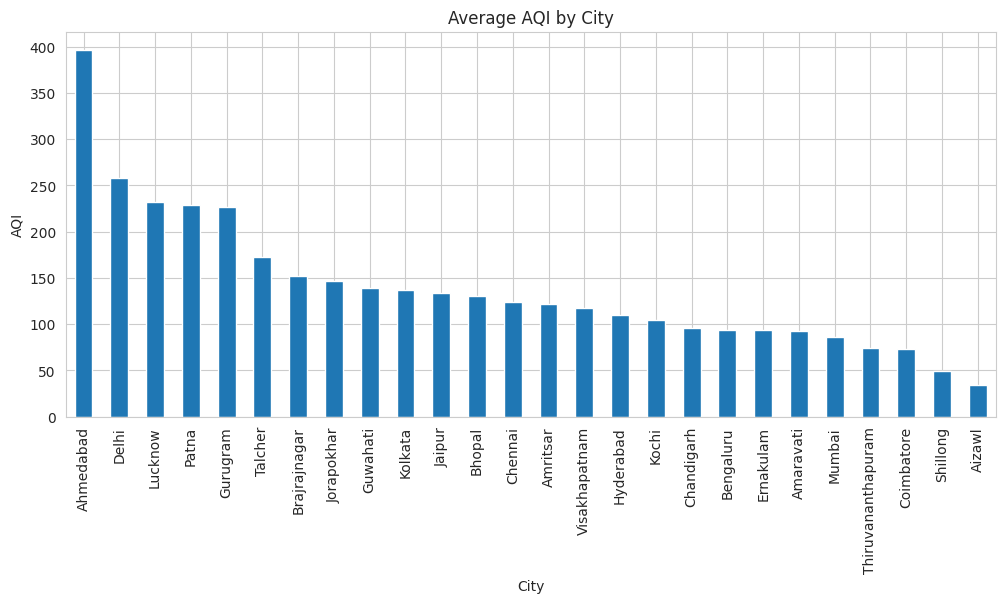

In [ ]:
df.groupby('City')['AQI'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12, 5))
plt.title('Average AQI by City')
plt.ylabel('AQI')
plt.show()

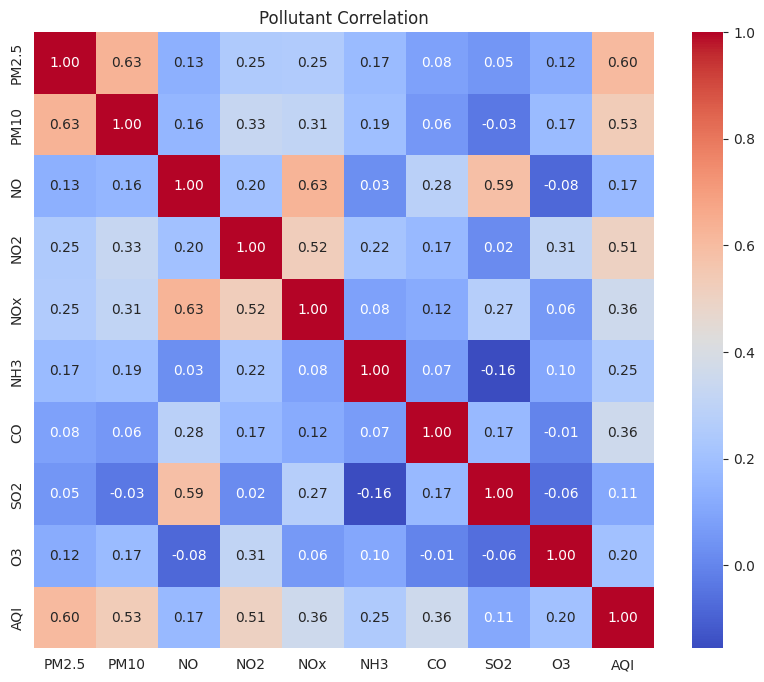

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include='number').drop(columns=['Month', 'Year']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Pollutant Correlation')
plt.show()

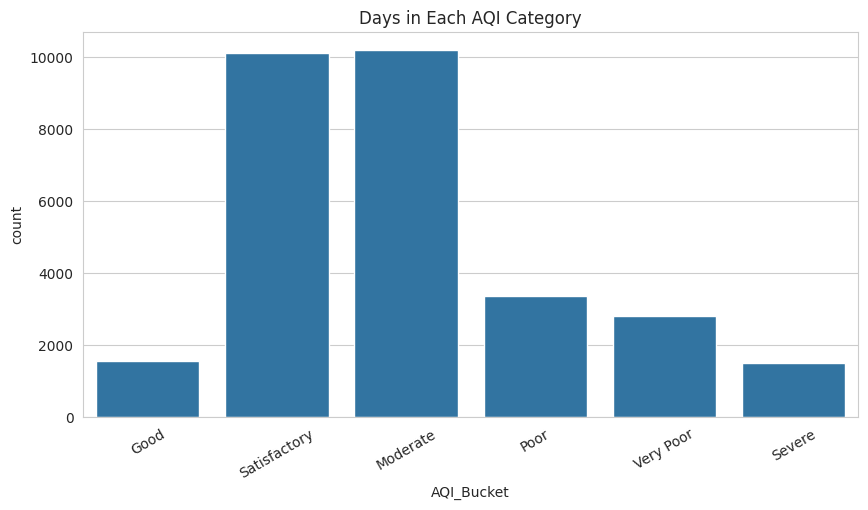

In [ ]:
order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='AQI_Bucket', order=order)
plt.title('Days in Each AQI Category')
plt.xticks(rotation=30)
plt.show()

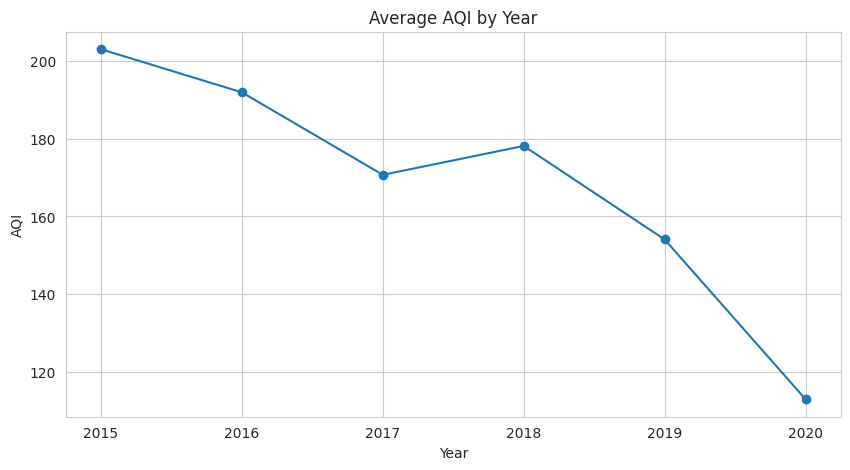

In [ ]:
df.groupby('Year')['AQI'].mean().plot(marker='o', figsize=(10, 5))
plt.title('Average AQI by Year')
plt.ylabel('AQI')
plt.show()

### Feature Engineering

In [ ]:
df['DayOfWeek'] = df['Date'].dt.dayofweek
df[['Date', 'DayOfWeek']].head()

,Date,DayOfWeek
0,2015-01-01,3
1,2015-01-02,4
2,2015-01-03,5
3,2015-01-04,6
4,2015-01-05,0


In [ ]:
df = df.sort_values(['City', 'Date'])

df['AQI_lag1'] = df.groupby('City')['AQI'].shift(1)
df['AQI_lag7'] = df.groupby('City')['AQI'].shift(7)

df[['City', 'Date', 'AQI', 'AQI_lag1', 'AQI_lag7']].head(10)

,City,Date,AQI,AQI_lag1,AQI_lag7
0,Ahmedabad,2015-01-01,209.0,NaN,NaN
1,Ahmedabad,2015-01-02,209.0,209.0,NaN
2,Ahmedabad,2015-01-03,209.0,209.0,NaN
3,Ahmedabad,2015-01-04,209.0,209.0,NaN
4,Ahmedabad,2015-01-05,209.0,209.0,NaN
5,Ahmedabad,2015-01-06,209.0,209.0,NaN
6,Ahmedabad,2015-01-07,209.0,209.0,NaN
7,Ahmedabad,2015-01-08,209.0,209.0,209.0
8,Ahmedabad,2015-01-09,209.0,209.0,209.0
9,Ahmedabad,2015-01-10,209.0,209.0,209.0


In [ ]:
df['AQI_roll7'] = df.groupby('City')['AQI'].transform(lambda x: x.rolling(7).mean())
df[['City', 'Date', 'AQI', 'AQI_roll7']].head(10)

,City,Date,AQI,AQI_roll7
0,Ahmedabad,2015-01-01,209.0,NaN
1,Ahmedabad,2015-01-02,209.0,NaN
2,Ahmedabad,2015-01-03,209.0,NaN
3,Ahmedabad,2015-01-04,209.0,NaN
4,Ahmedabad,2015-01-05,209.0,NaN
5,Ahmedabad,2015-01-06,209.0,NaN
6,Ahmedabad,2015-01-07,209.0,209.0
7,Ahmedabad,2015-01-08,209.0,209.0
8,Ahmedabad,2015-01-09,209.0,209.0
9,Ahmedabad,2015-01-10,209.0,209.0


In [ ]:
df.isna().sum()

,0
City,0
Date,0
PM2.5,0
PM10,2009
NO,0
NO2,0
NOx,1169
NH3,2009
CO,0
SO2,0


In [ ]:
df.to_csv('/content/drive/MyDrive/AQIdataset/city_day_features.csv', index=False)

<Axes: title={'center': 'Delhi AQI'}, xlabel='Date'>

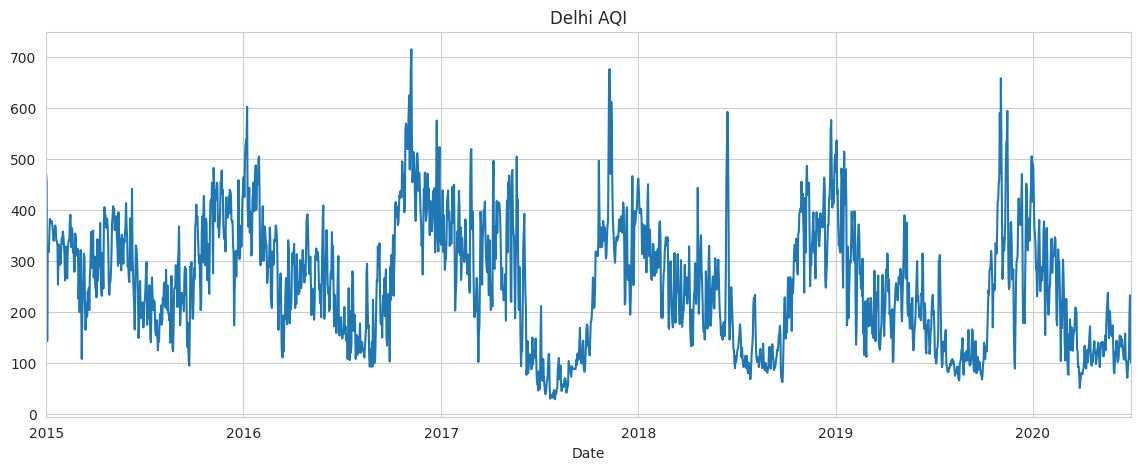

In [ ]:
delhi = df[df['City'] == 'Delhi'].set_index('Date')['AQI']
delhi = delhi.asfreq('D')
delhi = delhi.interpolate()
delhi.plot(figsize=(14, 5), title='Delhi AQI')

### ARIMA Modeling

In [ ]:
!pip install pmdarima -q
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 13.6 MB/s eta 0:00:00


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(delhi)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -3.431934347253979
p-value: 0.009917226121156452


/tmp/ipykernel_581/364837218.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(delhi)


In [ ]:
train_size = int(len(delhi) * 0.8)
train, test = delhi[:train_size], delhi[train_size:]
print('Train:', len(train), 'Test:', len(test))

Train: 1607 Test: 402


In [ ]:
auto_model = pm.auto_arima(train, seasonal=False, trace=True, suppress_warnings=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=17211.573, Time=5.77 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=17407.824, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=17406.167, Time=0.23 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=17402.710, Time=1.36 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=17405.848, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=17210.102, Time=3.00 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=17259.863, Time=2.38 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=17249.682, Time=2.06 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=17211.490, Time=6.51 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=17223.110, Time=2.63 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=17215.769, Time=2.64 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=7.72 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=17208.189, Time=1.14 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=17257.914, Time=0.54 sec
 ARIMA(1,1,1)(0,0,0)[0]  

In [ ]:
order = auto_model.order  # e.g. (2,1,2)
model = ARIMA(train, order=order)
fitted = model.fit()
print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1607
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -8600.095
Date:                Wed, 30 Sep 2026   AIC                          17208.189
Time:                        16:17:52   BIC                          17229.715
Sample:                    01-01-2015   HQIC                         17216.181
                         - 05-26-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4498      0.042     10.585      0.000       0.367       0.533
ma.L1         -0.5935      0.045    -13.336      0.000      -0.681      -0.506
ma.L2         -0.2424      0.028     -8.607      0.0

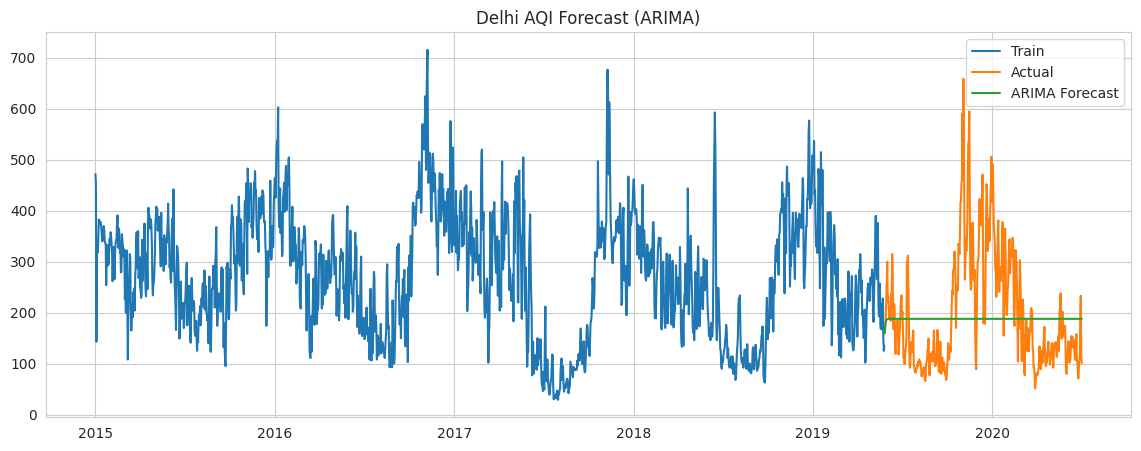

In [ ]:
forecast = fitted.forecast(steps=len(test))

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='ARIMA Forecast')
plt.legend()
plt.title('Delhi AQI Forecast (ARIMA)')
plt.show()

In [ ]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print('MAE:', round(mae, 2))
print('RMSE:', round(rmse, 2))
print('MAPE:', round(mape, 2), '%')

MAE: 90.36
RMSE: 114.07
MAPE: 53.21 %


### Prophet Modeling

In [ ]:
!pip install prophet -q
from prophet import Prophet

prophet_df = delhi.reset_index()
prophet_df.columns = ['ds', 'y']  # Prophet requires these exact column names
prophet_df.head()

,ds,y
0,2015-01-01,472.0
1,2015-01-02,454.0
2,2015-01-03,143.0
3,2015-01-04,319.0
4,2015-01-05,325.0


In [ ]:
train_p = prophet_df[:train_size]
test_p = prophet_df[train_size:]
print(len(train_p), len(test_p))

1607 402


In [ ]:
model_p = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_p.fit(train_p)

In [ ]:
future = model_p.make_future_dataframe(periods=len(test_p))
forecast_p = model_p.predict(future)

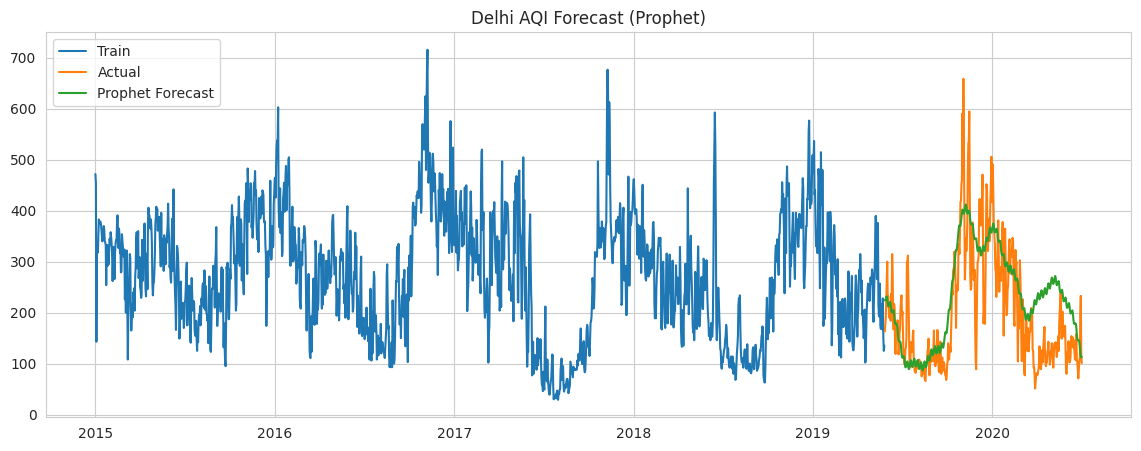

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(train_p['ds'], train_p['y'], label='Train')
plt.plot(test_p['ds'], test_p['y'], label='Actual')
plt.plot(forecast_p['ds'][-len(test_p):], forecast_p['yhat'][-len(test_p):], label='Prophet Forecast')
plt.legend()
plt.title('Delhi AQI Forecast (Prophet)')
plt.show()

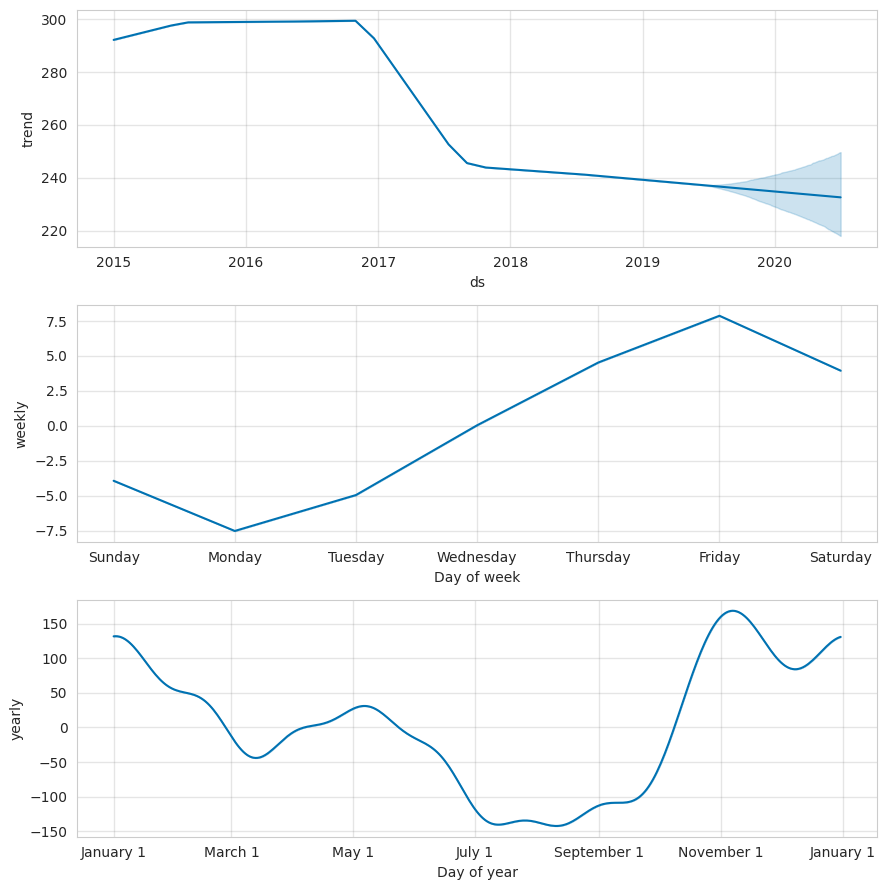

In [ ]:
model_p.plot_components(forecast_p)
plt.show()

In [ ]:
pred_p = forecast_p['yhat'][-len(test_p):].values
actual_p = test_p['y'].values

mae_p = mean_absolute_error(actual_p, pred_p)
rmse_p = np.sqrt(mean_squared_error(actual_p, pred_p))
mape_p = np.mean(np.abs((actual_p - pred_p) / actual_p)) * 100

print('MAE:', round(mae_p, 2))
print('RMSE:', round(rmse_p, 2))
print('MAPE:', round(mape_p, 2), '%')

MAE: 64.21
RMSE: 82.1
MAPE: 43.94 %


In [ ]:
model_future = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_future.fit(prophet_df)

In [ ]:
future_365 = model_future.make_future_dataframe(periods=365)
forecast_365 = model_future.predict(future_365)

### Future Forecast - Delhi (12 Months)

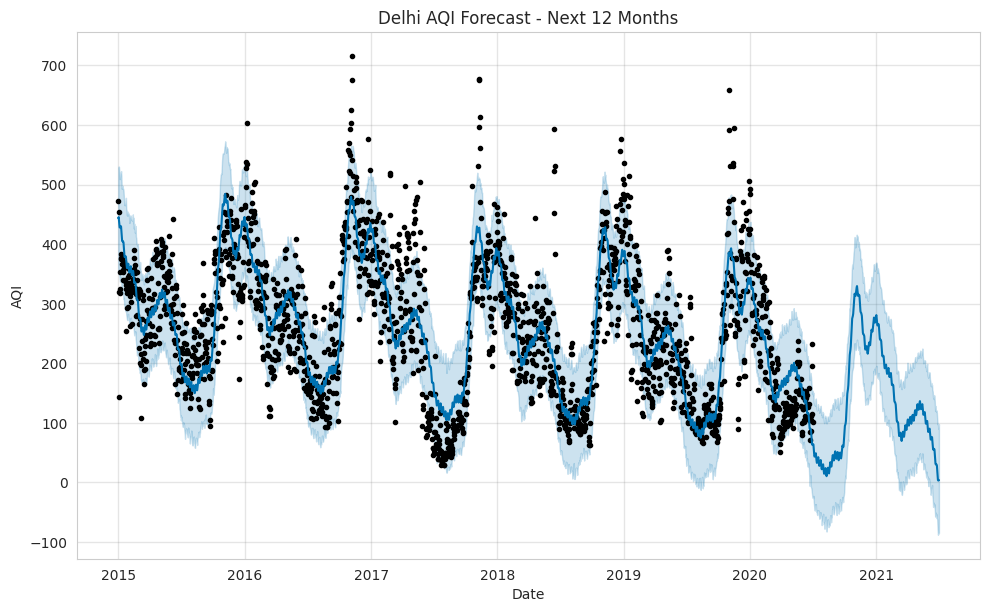

In [ ]:
fig = model_future.plot(forecast_365)
plt.title('Delhi AQI Forecast - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()

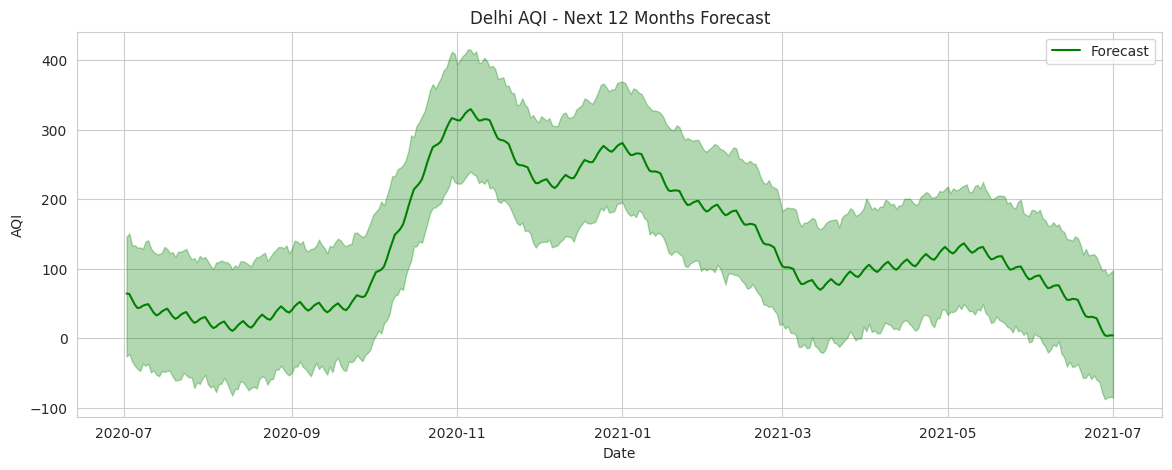

In [ ]:
future_only = forecast_365[forecast_365['ds'] > prophet_df['ds'].max()]

plt.figure(figsize=(14, 5))
plt.plot(future_only['ds'], future_only['yhat'], label='Forecast', color='green')
plt.fill_between(future_only['ds'], future_only['yhat_lower'], future_only['yhat_upper'], alpha=0.3, color='green')
plt.title('Delhi AQI - Next 12 Months Forecast')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()

In [ ]:
worst_days = future_only.sort_values('yhat', ascending=False).head(10)
worst_days[['ds', 'yhat']]

,ds,yhat
2136,2020-11-06,329.630007
2135,2020-11-05,327.332643
2137,2020-11-07,323.972444
2134,2020-11-04,323.662120
2133,2020-11-03,317.941956
2138,2020-11-08,317.857505
2129,2020-10-30,316.716881
2130,2020-10-31,315.460917
2141,2020-11-11,315.207978
2142,2020-11-12,314.969118


### Mumbai

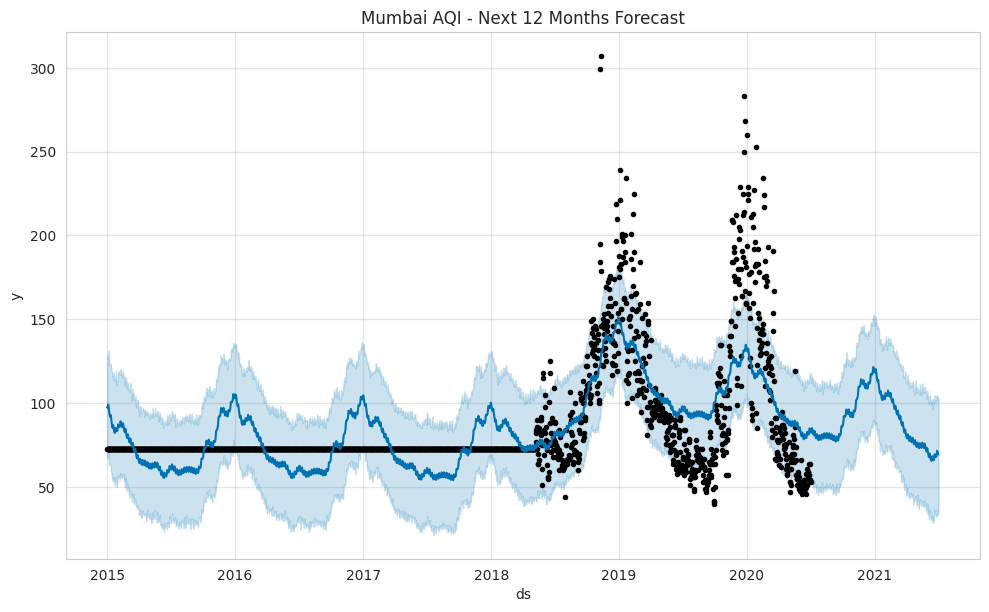

In [ ]:
city_name = 'Mumbai'

city_df = df[df['City'] == city_name].set_index('Date')['AQI'].asfreq('D').interpolate()
city_prophet_df = city_df.reset_index()
city_prophet_df.columns = ['ds', 'y']

model_city = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_city.fit(city_prophet_df)

future_city = model_city.make_future_dataframe(periods=365)
forecast_city = model_city.predict(future_city)

fig = model_city.plot(forecast_city)
plt.title(f'{city_name} AQI - Next 12 Months Forecast')
plt.show()

### Bengaluru

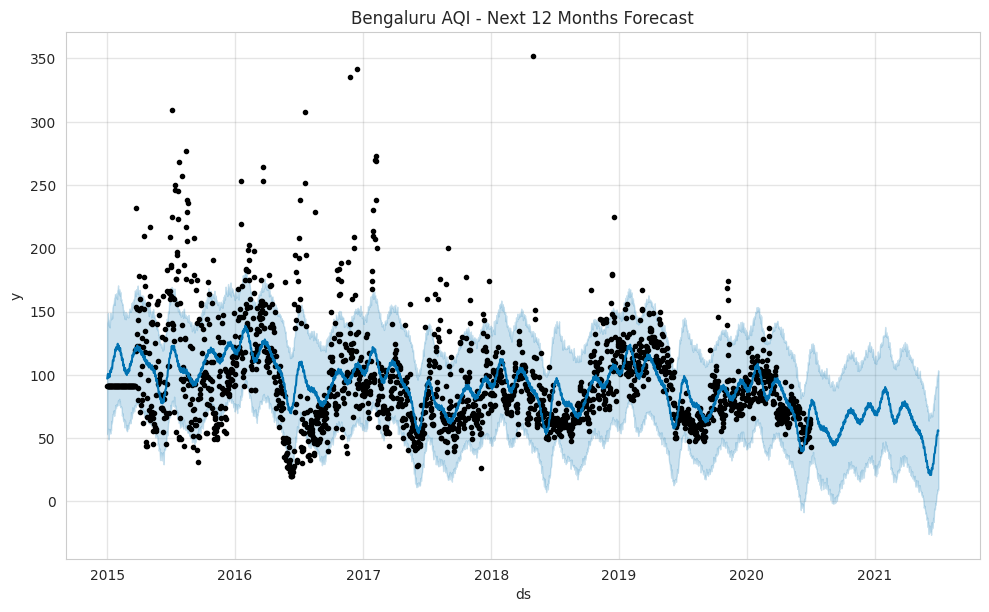

In [ ]:
city_name = 'Bengaluru'

city_df = df[df['City'] == city_name].set_index('Date')['AQI'].asfreq('D').interpolate()
city_prophet_df = city_df.reset_index()
city_prophet_df.columns = ['ds', 'y']

model_city = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_city.fit(city_prophet_df)

future_city = model_city.make_future_dataframe(periods=365)
forecast_city = model_city.predict(future_city)

fig = model_city.plot(forecast_city)
plt.title(f'{city_name} AQI - Next 12 Months Forecast')
plt.show()

### Kolkata

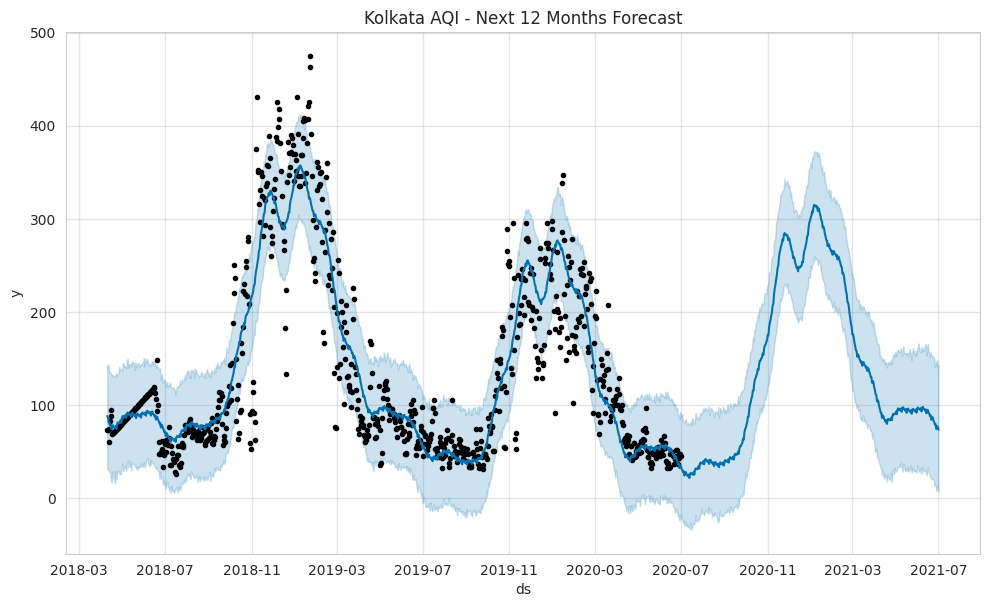

In [ ]:
city_name = 'Kolkata'

city_df = df[df['City'] == city_name].set_index('Date')['AQI'].asfreq('D').interpolate()
city_prophet_df = city_df.reset_index()
city_prophet_df.columns = ['ds', 'y']

model_city = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_city.fit(city_prophet_df)

future_city = model_city.make_future_dataframe(periods=365)
forecast_city = model_city.predict(future_city)

fig = model_city.plot(forecast_city)
plt.title(f'{city_name} AQI - Next 12 Months Forecast')
plt.show()

### AQI Forecasting (Deployment)

A Streamlit dashboard was additionally built to make this forecasting tool interactive, extending city coverage to 20 cities for broader usability.

KEY INSIGHTS

• Among the four cities studied, Delhi showed the worst air quality, with AQI regularly crossing 400-700 during winter, far higher than Mumbai, Kolkata, or Bengaluru.

• All four cities show a clear winter spike (Nov-Jan), driven by lower temperatures trapping pollutants and increased festival-related emissions. Delhi and Kolkata show the sharpest spikes, Mumbai a moderate rise, and Bengaluru the mildest, staying under 350 even at its peak.

• Diwali season consistently drives the yearly peak. For Delhi specifically, the model's own forecast independently flagged early November as the highest-risk period, without being told about the festival — the pattern emerged purely from historical seasonality.

• Prophet significantly outperformed ARIMA for forecasting AQI (MAPE: 43.94% vs 53.21%). ARIMA produced a near-flat forecast, unable to capture the seasonal spikes, while Prophet's built-in yearly seasonality modeling tracked the pattern much more closely.

• Bengaluru shows the cleanest and most stable air quality of the four, with a comparatively low baseline AQI and smaller seasonal swings.

RECOMMENDATIONS

• Stricter vehicle emission controls in winter months, especially in Delhi and Kolkata, where the seasonal spike is sharpest.

• Festival-based emission advisories — issue public health warnings and temporary restrictions (firecrackers, construction) in the weeks around Diwali, based on the model's ability to predict this spike in advance.

• Expansion of green zones and urban forestry, particularly in high-AQI cities, to help absorb pollutants during peak months.

• City-specific monitoring, since pollution drivers and severity clearly differ — a one-size-fits-all policy would under-address Delhi and over-address Bengaluru.

LIMITATIONS

• Data covers 2015-2020 (city_day.csv), so recent years are extrapolated, not directly observed.

• Prophet's confidence intervals occasionally dip below 0, a known modeling artifact since AQI cannot be negative — this doesn't affect the core forecast (yhat).
